8. In this exercise, we will generate simulated data, and will then use
this data to perform forward and backward stepwise selection.

(a) Create a random number generator and use its normal() method
to generate a predictor X of length n = 100, as well as a noise
vector ϵ of length n = 100.

In [2]:
import numpy as np

np.random.seed(1)

n = 100
X = np.random.normal(size = 100)
epsilon = np.random.normal(size = 100)

(b) Generate a response vector Y of length n = 100 according to
the model
Y= β0 + β1X + β2X2 + β3X3 + ϵ,
where β0, β1, β2, and β3 are constants of your choice.

In [3]:
beta0 = 4
beta1 = 3
beta2 = 2
beta3 = 1

Y = beta0 + beta1*X + beta2*(X**2) + beta3*(X**3) + epsilon

(c) Use forward stepwise selection in order to select a model contain-
ing the predictors X, X2, . . . , X10. What is the model obtained
according to Cp? Report the coefficients of the model obtained.

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression

X_powers = np.column_stack([X**k for k in range(1, 11)])
n, p_max = X_powers.shape

full_model = LinearRegression().fit(X_powers, Y)
y_full_pred = full_model.predict(X_powers)
rss_full = np.sum((Y - y_full_pred)**2)
p_full = p_max + 1
sigma2 = rss_full / (n - p_full)

remaining = list(range(p_max))
selected = []
models = []

for step in range(1, p_max + 1):
    best_cp_step = None
    best_var_step = None
    best_model_step = None

    for j in remaining:
        trial_vars = selected + [j]
        X_trial = X_powers[:, trial_vars]

        model = LinearRegression().fit(X_trial, Y)
        y_pred = model.predict(X_trial)
        rss = np.sum((Y - y_pred)**2)

        p = len(trial_vars) + 1
        cp = rss / sigma2 - (n - 2 * p)

        if (best_cp_step is None) or (cp < best_cp_step):
            best_cp_step = cp
            best_var_step = j
            best_model_step = model

    selected.append(best_var_step)
    remaining.remove(best_var_step)
    models.append((selected.copy(), best_cp_step, best_model_step))

best_subset, best_cp, best_model = min(models, key=lambda x: x[1])

feature_names = [f"X^{k}" for k in range(1, 11)]
print("best Cp index（0-based）:", best_subset)
print("best Cp variable names:", [feature_names[j] for j in best_subset])
print("best Cp:", best_cp)

print("\nRegression coefficients estimation:")
print("Intercept:", best_model.intercept_)
for idx, coef in zip(best_subset, best_model.coef_):
    print(f"{feature_names[idx]}: {coef}")

best Cp index（0-based）: [0, 1, 2, 5]
best Cp variable names: ['X^1', 'X^2', 'X^3', 'X^6']
best Cp: 2.8417780987847863

Regression coefficients estimation:
Intercept: 4.2769489859286125
X^1: 2.910076031620079
X^2: 1.657467373038928
X^3: 1.1053782617044865
X^6: 0.02094858787923326


(d) Repeat (c), using backwards stepwise selection. How does your
answer compare to the results in (c)?

In [5]:
from sklearn.linear_model import LinearRegression

n, p_max = X_powers.shape

all_vars = list(range(p_max))
selected = all_vars.copy()
models_b = []

X_curr = X_powers[:, selected]
model_full = LinearRegression().fit(X_curr, Y)
y_pred_full = model_full.predict(X_curr)
rss = ((Y - y_pred_full)**2).sum()
p = len(selected) + 1
cp = rss / sigma2 - (n - 2 * p)
models_b.append((selected.copy(), cp, model_full))

for step in range(p_max - 1):
    best_cp_step = None
    best_vars_step = None
    best_model_step = None

    for j in selected:
        trial_vars = [v for v in selected if v != j]
        X_trial = X_powers[:, trial_vars]

        model = LinearRegression().fit(X_trial, Y)
        y_pred = model.predict(X_trial)
        rss = ((Y - y_pred)**2).sum()
        p = len(trial_vars) + 1
        cp = rss / sigma2 - (n - 2 * p)

        if (best_cp_step is None) or (cp < best_cp_step):
            best_cp_step = cp
            best_vars_step = trial_vars
            best_model_step = model

    selected = best_vars_step
    models_b.append((selected.copy(), best_cp_step, best_model_step))

best_subset_b, best_cp_b, best_model_b = min(models_b, key=lambda x: x[1])

feature_names = [f"X^{k}" for k in range(1, 11)]

print("Backward best Cp index (0-based):", best_subset_b)
print("Backward best Cp variable names:", [feature_names[j] for j in best_subset_b])
print("Backward corresponding Cp value:", best_cp_b)

print("\nBackward Regression coefficients estimation:")
print("Intercept:", best_model_b.intercept_)
for idx, coef in zip(best_subset_b, best_model_b.coef_):
    print(f"{feature_names[idx]}: {coef}")

Backward best Cp index (0-based): [0, 1, 4, 5, 6, 8]
Backward best Cp variable names: ['X^1', 'X^2', 'X^5', 'X^6', 'X^7', 'X^9']
Backward corresponding Cp value: 4.765916556660741

Backward Regression coefficients estimation:
Intercept: 4.3124890228384976
X^1: 3.1889238173540173
X^2: 1.5500900982858539
X^5: 1.0315213375794325
X^6: 0.027634377186989096
X^7: -0.31858918501048983
X^9: 0.030903196320220205


(e) Now fit a lasso model to the simulated data, again using X, X2
,
. . . , X10 as predictors. Use cross-validation to select the optimal
value of λ. Create plots of the cross-validation error as a function
of λ. Report the resulting coefficient estimates, and discuss the
results obtained.

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt



alphas = np.logspace(-4, 1, 100)
lasso_model = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=alphas, cv=10, random_state=1, max_iter=10000)
)

lasso_model.fit(X_powers, Y)

lasso_cv = lasso_model.named_steps['lassocv']

best_alpha = lasso_cv.alpha_
coefs = lasso_cv.coef_
intercept = lasso_cv.intercept_

print("best λ (alpha):", best_alpha)

feature_names = [f"X^{k}" for k in range(1, 11)]
print("\nLasso coefficient：")
print("intercept:", intercept)
for name, c in zip(feature_names, coefs):
    print(f"{name}: {c}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.5210161802868782, tolerance: 0.27655361820044194
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.7677957500687782, tolerance: 0.27655361820044194
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.9981752656775029, tolerance: 0.27655361820044194
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Conve

best λ (alpha): 0.011768119524349979

Lasso coefficient：
intercept: 6.04840144981536
X^1: 2.573777002321475
X^2: 1.700812972770043
X^3: 2.7948437399658737
X^4: 0.4183283560899142
X^5: 0.0
X^6: 0.16841841283602885
X^7: 0.0
X^8: 0.0
X^9: 0.0
X^10: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4.243794698787994, tolerance: 0.32153533584157207
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4.976032200443257, tolerance: 0.32153533584157207
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.608757071130967, tolerance: 0.32153533584157207
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Converge

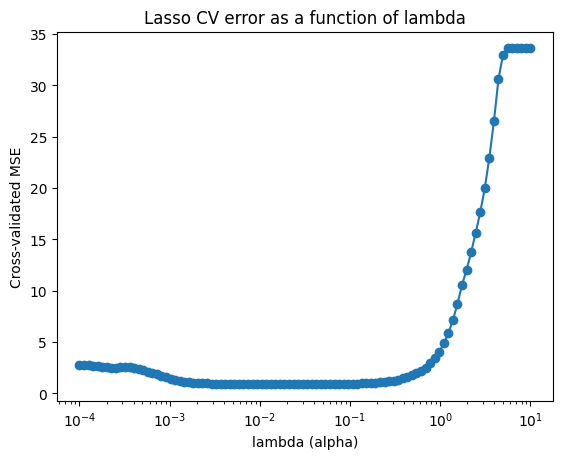

In [7]:
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure()
plt.plot(lasso_cv.alphas_, mean_mse, marker="o")
plt.xscale("log")
plt.xlabel("lambda (alpha)")
plt.ylabel("Cross-validated MSE")
plt.title("Lasso CV error as a function of lambda")
plt.show()

the error is lowest when alpha is 10^-3~1

(f) Now generate a response vector Y according to the model
Y= β0 + β7X7 + ϵ,
and perform forward stepwise selection and the lasso. Discuss
the results obtained.

In [8]:
beta0_f = 1
beta7_f = 7
Y_f = beta0_f + beta7_f * (X**7) + epsilon


In [9]:
from sklearn.linear_model import LinearRegression
import numpy as np

n, p_max = X_powers.shape

full_model_f = LinearRegression().fit(X_powers, Y_f)
y_full_pred_f = full_model_f.predict(X_powers)
rss_full_f = np.sum((Y_f - y_full_pred_f)**2)
p_full = p_max + 1
sigma2_f = rss_full_f / (n - p_full)

remaining = list(range(p_max))
selected = []
models_f = []

for step in range(1, p_max + 1):
    best_cp_step = None
    best_var_step = None
    best_model_step = None

    for j in remaining:
        trial_vars = selected + [j]
        X_trial = X_powers[:, trial_vars]

        model = LinearRegression().fit(X_trial, Y_f)
        y_pred = model.predict(X_trial)
        rss = np.sum((Y_f - y_pred)**2)

        p = len(trial_vars) + 1
        cp = rss / sigma2_f - (n - 2 * p)

        if (best_cp_step is None) or (cp < best_cp_step):
            best_cp_step = cp
            best_var_step = j
            best_model_step = model

    selected.append(best_var_step)
    remaining.remove(best_var_step)
    models_f.append((selected.copy(), best_cp_step, best_model_step))

best_subset_f, best_cp_f, best_model_f = min(models_f, key=lambda x: x[1])

feature_names = [f"X^{k}" for k in range(1, 11)]
print("Forward(f) best Cp index（0-based）:", best_subset_f)
print("Forward(f) best Cp variable names:", [feature_names[j] for j in best_subset_f])
print("Forward(f) best Cp:", best_cp_f)

print("\nForward(f) Regression coefficients estimation:")
print("Intercept:", best_model_f.intercept_)
for idx, coef in zip(best_subset_f, best_model_f.coef_):
    print(f"{feature_names[idx]}: {coef}")

Forward(f) best Cp index（0-based）: [6, 9, 1]
Forward(f) best Cp variable names: ['X^7', 'X^10', 'X^2']
Forward(f) best Cp: 2.0515659933349184

Forward(f) Regression coefficients estimation:
Intercept: 1.2293633618014925
X^7: 7.004277513885547
X^10: 0.0006421206685948146
X^2: -0.19107608475634769


Lasso(f) best λ (alpha): 0.06734150657750822

Lasso(f) coefficient：
intercept:  -2.1612356978050835
X^1: -0.06085968543410322
X^2: -0.3384324768426175
X^3: -17.58674234301888
X^4: -2.146759840320369
X^5: 108.97038708758856
X^6: -0.0
X^7: 169.99745788219732
X^8: 0.0
X^9: 94.86591733799717
X^10: 3.449155026281284


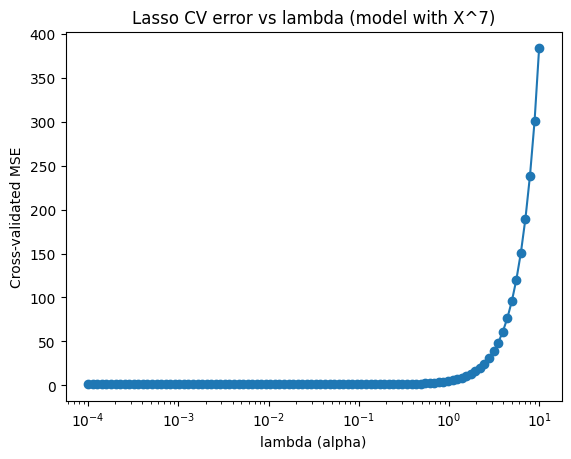

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

alphas = np.logspace(-4, 1, 100)

lasso_model_f = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=alphas, cv=10, random_state=1)
)

lasso_model_f.fit(X_powers, Y_f)

lasso_cv_f = lasso_model_f.named_steps['lassocv']
best_alpha_f = lasso_cv_f.alpha_
coefs_f = lasso_cv_f.coef_
intercept_f = lasso_cv_f.intercept_

print("Lasso(f) best λ (alpha):", best_alpha_f)

print("\nLasso(f) coefficient：")
print("intercept: ", intercept_f)
for name, c in zip(feature_names, coefs_f):
    print(f"{name}: {c}")

mean_mse_f = lasso_cv_f.mse_path_.mean(axis=1)

plt.figure()
plt.plot(lasso_cv_f.alphas_, mean_mse_f, marker="o")
plt.xscale("log")
plt.xlabel("lambda (alpha)")
plt.ylabel("Cross-validated MSE")
plt.title("Lasso CV error vs lambda (model with X^7)")
plt.show()


forward stepwise has better estimated coefficient